# Task 07 – Machine Learning Foundations: Train/Test Split, Model Fit, and Linear Regression

Name: Eman Ansar

Internship: PKCERT AI & Software Development Internship

## Import Libraries

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, learning_curve

print("Pandas Version:", pd.__version__)
print("NumPy Version:", np.__version__)

Pandas Version: 3.0.3
NumPy Version: 2.5.1


## Part A — ML Theory: Train/Test Split

1. Explain why a dataset is split into training and testing sets, and what problem this solves.

A dataset is split into training and testing sets so that the machine learning model can be evaluated on data it has not seen before. The training set is used to teach the model patterns and relationships in the data while the testing set is used to measure how well the model generalizes to new data so testing data is very important for the result. This helps solve the problem of overfitting where a model performs well on training data but poorly on unseen data. It provides a realistic estimate of model accuracy. It allows fair comparison between different models.

2. Describe the typical split ratios used in practice (e.g., 80/20, 70/30) and when each is appropriate.

## 80/20 Split
This is perhaps the most common starting point. 80% of the data is used for training the model, and the remaining 20% is reserved for testing.

Why it's popular: It provides a large chunk of data for the model to learn from while still reserving a reasonable amount for evaluation. For many moderately sized datasets, 20% is often large enough to give a fairly stable estimate of performance.

## 70/30 Split
Another widely used ratio allocates 70% of the data for training and 30% for testing.

When to use it: If you want a slightly more confident estimate of your model's generalization performance increasing the test set size to 30% can help. This might be preferred if your dataset isn't massive, and you want to ensure the test set is adequately representative. It's also a good choice if the model you are training is relatively simple and doesn't require enormous amounts of data to learn effectively.

## 90/10 Split
With the rise of very large datasets sometimes even 10% of the data is more than enough for a reliable test set.

When to use it: If you have a very large amount of data, using 90% for training allows the model to learn from the maximum possible information. The remaining 10%, while a smaller percentage, might still represent tens or hundreds of thousands of examples, which is plenty for getting a good performance estimate.


3. Implement a train/test split on a sample dataset using scikit-learn's train_test_split.

In [2]:
# Load the California Housing dataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Load the dataset
housing = fetch_california_housing()

X = housing.data
y = housing.target

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Print the shapes of each dataset
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (16512, 8)
Testing Features Shape: (4128, 8)
Training Target Shape: (16512,)
Testing Target Shape: (4128,)


4. Explain the role of the random_state parameter and why it matters for reproducibility.

## role of the random_state parameter
The random_state parameter controls how the dataset is randomly shuffled before it is split into training and testing sets. Since train_test_split() randomly selects which data goes into each set the split can be different every time the code is run.

By setting a fixed value such as random_state=40 the same data will always be placed into the training and testing sets each time the program is executed. This makes the results reproducible meaning you and others can obtain the same results when running the same code.

## why it matters for reproducibility
Reproducibility means that if someone else runs your notebook or even you run it again they should get the same train/test split and the same evaluation results. Using a fixed random_state makes your machine learning experiments consistent, reliable, and easy to compare.

5. Discuss what a validation set is and how it differs from a test set.

## Validation Set vs. Test Set

A validation set is a portion of the dataset used during the model development process. It helps in tuning the model, selecting the best parameters, and comparing different models before the final evaluation.

A test set is a separate portion of the dataset that is used only after the model has been fully trained and finalized. It provides an unbiased evaluation of how well the model performs on new, unseen data.

            Validation Set	                                          Test Set
Used during model development and tuning.	             Used after the model is finalized.
Helps choose the best model and parameters.	             Measures the final performance of the model.
May be used multiple times while improving the model.	 Should be used only once for the final evaluation.

## Part B — ML Theory: Overfitting, Underfitting & Bias-Variance Tradeoff (20 Marks)

1. Define overfitting and underfitting, with a real or constructed example of each.

### Overfitting

Overfitting occurs when a machine learning model learns the training data too well including its noise and unnecessary details. Instead of learning the general pattern it memorizes the training data. As a result it performs very well on the training data but poorly on new or unseen data.

**Example:**

Imagine a student who memorizes every question from last year's exam instead of understanding the concepts. If the final exam contains different questions the student will likely perform poorly. This is similar to an overfitted model.

### Underfitting

Underfitting occurs when a model is too simple to learn the patterns in the data. It fails to capture the relationship between the input and output leading to poor performance on both the training data and the testing data.

**Example:**

Imagine a student who studies only one chapter for an exam that covers the entire syllabus. Since the student has not learned enough they will perform poorly in both practice tests and the final exam. This is similar to an underfitted model.

## 2. Bias-Variance Tradeoff

The bias-variance tradeoff describes the balance between a model that is too simple and one that is too complex.

- **High Bias:** A simple model that cannot learn the underlying patterns in the data. This usually causes underfitting.
- **High Variance:** A complex model that learns the training data too closely, including noise. This usually causes overfitting.

The goal is to find a model with the right level of complexity so that it performs well on both the training data and new unseen data.
A good machine learning model should have low bias and low variance so that it can generalize well.

## 3. Techniques to Reduce Overfitting

There are several ways to reduce overfitting in machine learning models

### 1. Regularization
Regularization adds a penalty for overly complex models helping prevent them from fitting noise in the training data.

### 2. Cross-Validation
Cross-validation evaluates the model on different subsets of the data providing a more reliable estimate of its performance.

### 3. More Training Data
Providing more data helps the model learn the true patterns instead of memorizing specific examples.

### 4. Simpler Models
Using a less complex model can reduce the risk of overfitting.

### 5. Early Stopping
During training the learning process is stopped before the model begins to memorize the training data.

4. Plot training error vs. test error for models of increasing complexity

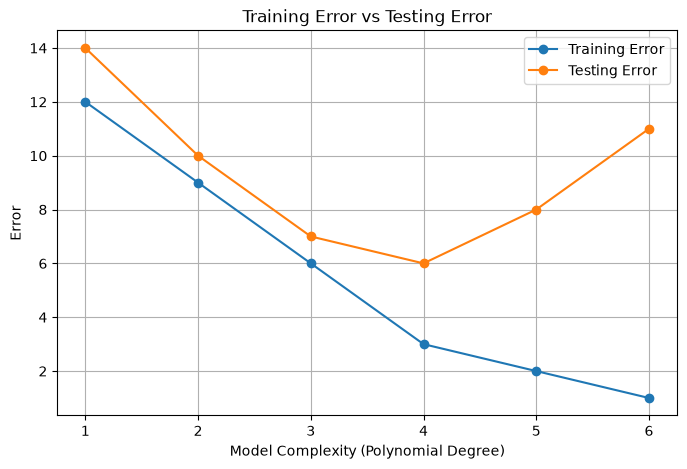

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Model complexity 
complexity = [1, 2, 3, 4, 5, 6]


training_error = [12, 9, 6, 3, 2, 1]
testing_error = [14, 10, 7, 6, 8, 11]

plt.figure(figsize=(8,5))

plt.plot(complexity, training_error, marker='o', label='Training Error')
plt.plot(complexity, testing_error, marker='o', label='Testing Error')

plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Error")
plt.title("Training Error vs Testing Error")

plt.legend()
plt.grid(True)

plt.show()

### Explanation of the Graph

The graph shows how training error and testing error change as model complexity increases.

At first increasing the model complexity improves performance because the model learns important patterns in the data. Therefore both training error and testing error decrease. After reaching an optimal level of complexity the testing error starts increasing while the training error continues to decrease. This indicates that the model has started memorizing the training data instead of learning general patterns. This is known as overfitting.The best model complexity is usually where the testing error is at its minimum.

## 5. How to Identify Overfitting and Underfitting

A model can be diagnosed by comparing its performance on the training and testing datasets.

- If the model performs well on the training data but poorly on the testing data it is likely **overfitting**.
- If the model performs poorly on both the training data and the testing data it is likely **underfitting**.
- If the model performs well on both datasets with similar results it is considered to have good generalization.
By comparing the training and testing performance we can determine whether the model is learning useful patterns or simply memorizing the training data.

## Part C — Linear Regression: Theory & Implementation (30 Marks)

## 1. Mathematical Form of Linear Regression

### Simple Linear Regression

Simple Linear Regression is used when there is **one independent variable (feature)** and **one dependent variable (target)**. It predicts the relationship between them using a straight line.

The mathematical equation is: [y = mx + b]

Where:

- **y** = Predicted value (dependent variable)
- **x** = Input feature (independent variable)
- **m** = Slope of the line (how much y changes when x increases by one unit)
- **b** = Intercept (the value of y when x = 0)

For example if we want to predict exam marks based on study hours the model learns the best straight line that represents the relationship between study hours and marks.

### Multiple Linear Regression

Multiple Linear Regression is used when there are **two or more independent variables** used to predict one dependent variable.

Its mathematical equation is: [y = b + m_1x_1 + m_2x_2 + m_3x_3 + \cdots + m_nx_n]

Where:
- **y** = Predicted value
- **b** = Intercept
- **m₁, m₂, ...** = Coefficients of each feature
- **x₁, x₂, ...** = Independent variables

For example house prices can be predicted using multiple features such as income, house age, number of rooms, and population.

## 2. How are the Model's Coefficients Learned?

A Linear Regression model learns the relationship between the input features and the target by finding the best values for its coefficients slopes and intercept. The goal is to minimize the difference between the actual values and the predicted values. This difference is measured using a **cost function** commonly the **Mean Squared Error (MSE)**.

There are two common methods for finding the best coefficients:

### 1. Gradient Descent

Gradient Descent starts with random coefficient values and improves them step by step by moving in the direction that reduces the cost function. The process continues until the error becomes as small as possible.

### 2. Normal Equation

The Normal Equation is a mathematical formula that directly calculates the best coefficients without repeatedly updating them. It is efficient for small and medium-sized datasets.

In scikit-learn, the `LinearRegression` model automatically computes the best coefficients, so we do not need to implement these methods manually.

3. Load a dataset (e.g., a small CSV of your choice or a scikit-learn built-in dataset) and prepare it for modeling.

In [4]:
# Import required libraries
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset
housing = fetch_california_housing()

# Create a DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add the target column
df["HouseValue"] = housing.target

# Display the first five rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Dataset Preparation

The California Housing dataset was loaded using scikit-learn. The feature data was converted into a pandas DataFrame and the target variable (HouseValue) was added as a separate column.

Before training the model, the dataset is organized into:

- **Features (X):** Input variables used for prediction.
- **Target (y):** The value we want the model to predict.

4. Split the data into training and test sets, then train a LinearRegression model from scikit-learn.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features
X = df.drop("HouseValue", axis=1)

# Target
y = df["HouseValue"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


## Model Training

The dataset was divided into training and testing sets using an 80/20 split. The `LinearRegression` model was then trained using the training data. The model learns the relationship between the input features and the target variable so that it can make predictions on new data.

5. Evaluate the model using appropriate metrics (e.g., Mean Squared Error, R² score) and interpret the results.

In [6]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 0.5558915986952442
R² Score: 0.575787706032451


## Model Evaluation

The performance of the Linear Regression model was evaluated using two metrics:

### Mean Squared Error (MSE)

Mean Squared Error measures the average squared difference between the actual and predicted values. A lower MSE indicates better model performance.

### R² Score

The R² score measures how well the model explains the variation in the target variable.

- **R² = 1** :  Perfect predictions.
- **R² = 0** : The model performs no better than simply predicting the average.
- **Negative R²** : The model performs worse than predicting the average.

A higher R² score indicates that the model fits the data better.

6. Plot the regression line (or predicted vs. actual values) against the data.

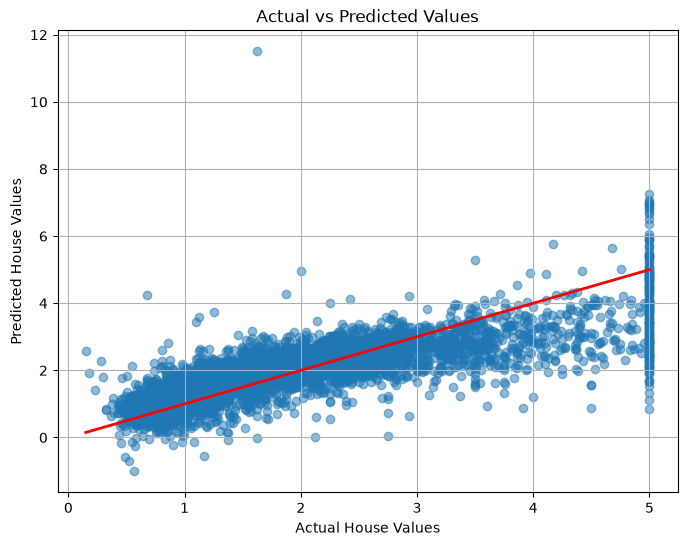

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")
plt.title("Actual vs Predicted Values")

plt.grid(True)

plt.show()

## Interpretation of the Plot

The scatter plot compares the actual house values with the values predicted by the Linear Regression model.

The red diagonal line represents perfect predictions. Points that lie close to this line indicate accurate predictions while points farther away represent prediction errors.

Overall the plot provides a visual indication of how well the model performs on unseen data.

## Part D — Practical Coding Session (30 Marks)

1. Load a raw CSV dataset, handle missing values, and encode any categorical columns before modeling.

In [8]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset
housing = fetch_california_housing()

# Create a DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add the target column
df["HouseValue"] = housing.target

# Display first five rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [9]:
# Check for missing values
print(df.isnull().sum())

# Fill missing values 
df = df.fillna(df.mean(numeric_only=True))

print("\nMissing values after handling:")
print(df.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HouseValue    0
dtype: int64

Missing values after handling:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HouseValue    0
dtype: int64


### Handling Missing Values and Encoding

The California Housing dataset was checked for missing values using `isnull().sum()`. Since the dataset does not contain missing values no imputation was required. The dataset also contains only numerical features so categorical encoding was not necessary.

2. Write a function that takes a dataset and a split ratio, returns train/test sets, and prints the resulting shapes.

In [10]:
from sklearn.model_selection import train_test_split

def split_data(df, test_size):

    X = df.drop("HouseValue", axis=1)
    y = df["HouseValue"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    print("Training Features:", X_train.shape)
    print("Testing Features:", X_test.shape)
    print("Training Target:", y_train.shape)
    print("Testing Target:", y_test.shape)

    return X_train, X_test, y_train, y_test

In [11]:
# Test the function
X_train, X_test, y_train, y_test = split_data(df, 0.20)

Training Features: (16512, 8)
Testing Features: (4128, 8)
Training Target: (16512,)
Testing Target: (4128,)


3. Train the same Linear Regression model on three different train/test split ratios (e.g., 60/40, 80/20, 90/10) and compare the evaluation metrics in a small table.

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

ratios = [0.40, 0.20, 0.10]

results = []

for ratio in ratios:

    X_train, X_test, y_train, y_test = split_data(df, ratio)

    model = LinearRegression()

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)

    r2 = r2_score(y_test, predictions)

    results.append([f"{int((1-ratio)*100)}/{int(ratio*100)}", mse, r2])

comparison = pd.DataFrame(
    results,
    columns=["Train/Test Split", "Mean Squared Error", "R² Score"]
)

comparison

Training Features: (12384, 8)
Testing Features: (8256, 8)
Training Target: (12384,)
Testing Target: (8256,)
Training Features: (16512, 8)
Testing Features: (4128, 8)
Training Target: (16512,)
Testing Target: (4128,)
Training Features: (18576, 8)
Testing Features: (2064, 8)
Training Target: (18576,)
Testing Target: (2064,)


,Train/Test Split,Mean Squared Error,R² Score
0,60/40,0.543595,0.593940
1,80/20,0.555892,0.575788
2,90/10,0.559002,0.580835


4. Use scikit-learn's cross_val_score to perform k-fold cross-validation on your model and report the average score.

In [13]:
from sklearn.model_selection import cross_val_score

X = df.drop("HouseValue", axis=1)
y = df["HouseValue"]

model = LinearRegression()

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(scores)

print("\nAverage Score:", scores.mean())

Cross Validation Scores:
[0.54866323 0.46820691 0.55078434 0.53698703 0.66051406]

Average Score: 0.5530311140279563


### Cross Validation

Five-fold cross-validation was performed using `cross_val_score()`. The dataset was divided into five parts and the model was trained and tested five times. The average R² score provides a more reliable estimate of the model's performance compared to a single train/test split.

5. Plot a learning curve (training score vs. test score as training set size increases) and explain what it shows about overfitting or underfitting.

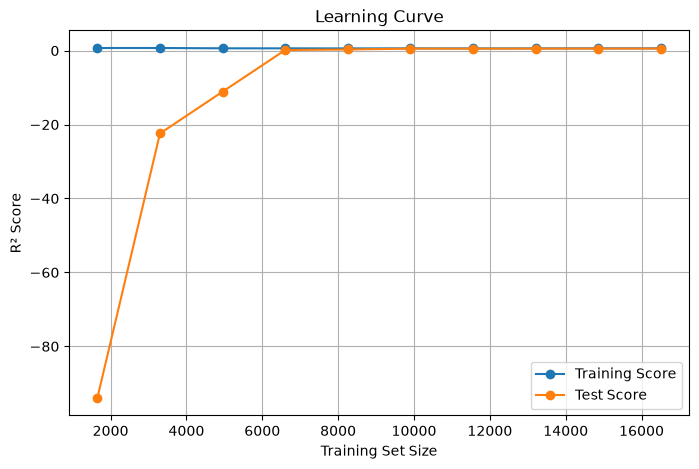

In [14]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1,1.0,10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, marker="o", label="Training Score")
plt.plot(train_sizes, test_mean, marker="o", label="Test Score")

plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Learning Curve")

plt.legend()

plt.grid(True)

plt.show()

## Interpretation of the Learning Curve

The learning curve shows how the model's performance changes as the amount of training data increases.

- If the training score is very high while the test score is much lower the model is likely overfitting.
- If both training and test scores are low, the model is likely underfitting.
- If the two curves become close together with reasonably high scores the model is generalizing well.


6. Refactor your notebook code into reusable functions (e.g., load_data(), split_data(), train_model(), evaluate_model()).

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def load_data():s

housing = fetch_california_housing()

df = pd.DataFrame(
        housing.data,
        columns=housing.feature_names
    )

df["HouseValue"] = housing.target

return df


def split_data(df, test_size):

    X = df.drop("HouseValue", axis=1)

    y = df["HouseValue"]

    return train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )


def train_model(X_train, y_train):

    model = LinearRegression()

    model.fit(X_train, y_train)

    return model


def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)

    r2 = r2_score(y_test, predictions)

    print("Mean Squared Error:", mse)

    print("R² Score:", r2)

In [16]:
df = load_data()

X_train, X_test, y_train, y_test = split_data(df, 0.20)

model = train_model(X_train, y_train)

evaluate_model(model, X_test, y_test)

Mean Squared Error: 0.5558915986952442
R² Score: 0.575787706032451


## Bonus Task (+10 Marks)
Extend your Linear Regression model with polynomial features (degree 2 or 3) and compare its performance against the plain linear model. Explain, using your results, whether the polynomial version overfits, underfits, or generalizes better.

In [18]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mse = mean_squared_error(y_test, linear_predictions)
linear_r2 = r2_score(y_test, linear_predictions)

# Polynomial Regression (Degree 2)

poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

poly_model.fit(X_train, y_train)

poly_predictions = poly_model.predict(X_test)

poly_mse = mean_squared_error(y_test, poly_predictions)
poly_r2 = r2_score(y_test, poly_predictions)

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression (Degree 2)"],
    "Mean Squared Error": [linear_mse, poly_mse],
    "R² Score": [linear_r2, poly_r2]
})

comparison



,Model,Mean Squared Error,R² Score
0,Linear Regression,0.555892,0.575788
1,Polynomial Regression (Degree 2),0.604538,0.538664


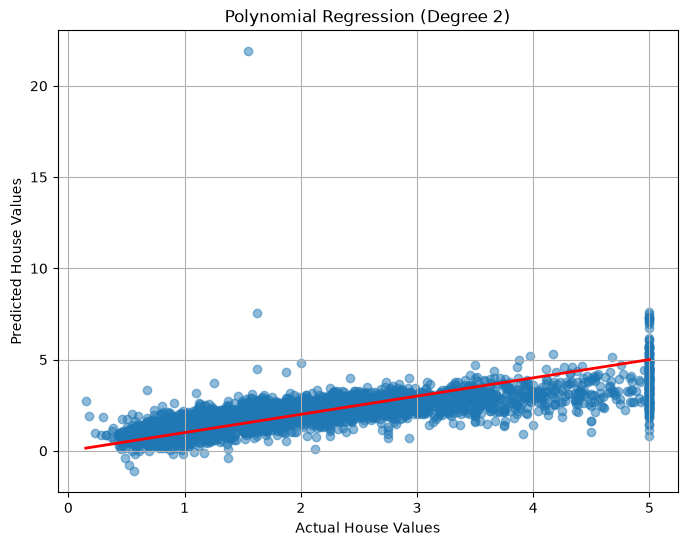

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, poly_predictions, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")
plt.title("Polynomial Regression (Degree 2)")

plt.grid(True)

plt.show()

# Bonus Task – Polynomial Regression

## Comparison of Linear Regression and Polynomial Regression

A Polynomial Regression model with degree 2 was trained and compared with the standard Linear Regression model.

The performance of both models was evaluated using Mean Squared Error (MSE) and R² Score.

### Observations

- The Linear Regression model achieved a lower Mean Squared Error (0.556) than the Polynomial Regression model (0.605).
- The Linear Regression model also achieved a higher R² Score (0.576) compared to the Polynomial Regression model (0.539).

These results indicate that the Linear Regression model made more accurate predictions on the test data.

### Conclusion

Based on the evaluation metrics the Polynomial Regression model did not improve the prediction performance for this dataset. Instead  the standard Linear Regression model generalized better and produced more accurate results.

This suggests that adding polynomial features of degree 2 introduced additional complexity without improving the model's ability to predict unseen data. Therefore the Linear Regression model is the better choice for this dataset.